# **From Curb to Comfort: Connecting LA County’s Vehicle Residents with Parking Garage Vacancy**

*UP213 Urban Data Science SQ25*

**Group Members:** Simon Han, Tomohiro Ujikawa


### Background
Vehicle residency is rising among working-class individuals and families as housing costs continue to outpace wages in Los Angeles and other big cities. On any given night in Los Angeles County, over 10,000 households sleep in cars, vans, or RVs, often within sight of nearly empty parking garages. We think support and resources could be better aligned in places where there’s a big need for safe parking and where there are large parking facilities available.

### Our Approach
We started by mapping where people already sleep curbside; we then asked why the pattern looks the way it does; finally, we scraped online forums to ground-truth what people say vehicle residents need.

### Key Questions
- How are vehicle residents clustered in Los Angeles?
- Which parts of Los Angeles have excess parking supply and high concentations of vehicle residents?

### Data Sources
- **LAHSA Homeless Count**: vehicle dwelling counts by tract
- **Census ACS**: poverty, rent burden, vehicle ownership, housing overcrowding, etc.
- **TIGER/Line**: Census tract boundaries for spatial analysis
- **SCAG 2019 Regional Land Use Type**: public parking facilities (LU19 code 1247)
- **Public Facilities Data**: locations of essential services (hospitals, schools, transportation hubs, and food pantries)
- **Reddit Data**: posts and comments from r/urbancarliving, r/vanlife, r/vandwelling, r/rvliving, r/homeless

### What we did
- **Spatial mapping**: Kernel-density heat-maps show that just 14 percent of census tracts host half of all curb-sleeping incidents recorded by outreach teams.
- **Predictive model**: A random-forest explains 63 percent of tract-level variation, with poverty rate, rent burden, and night-time curb supply emerging as the strongest predictors.
- **Clustering analysis**: K-means groups tracts into three recurring patterns of need: “hot-spot cores,” “spillover edges,” and “cold zones.”
- **Natural Language Processing**: Topic modeling and sentiment analysis of 83 k Reddit comments show the practical amenities people mention most (e.g. bathrooms, showers, power hookups) and the pain points that carry a strongly negative charge (e.g. policing, ticketing, noise).

### What we learned
- The hot-spot tracts overlap with garages that run >65 % vacant overnight—a spatial mismatch we can fix.
- Amenities that show up in negative-sentiment contexts (restrooms, lighting, security) are precisely the ones that must be built into any garage-based safe-parking pilot.

### What we recommend
- Launch a garaged-based safe parking pilot in 14 "hot-spot core" census tracts.
- Tie garage retrofits to the three top-ranked comfort amenities.
- Evaluate success by measuring the decrease in curbside unsheltered vehice count within .5km of a given parking garage.

# Data Preparation

Load required libraries and prepare geographic boundaries for analysis.

In [1]:
import contextily as ctx
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import warnings
import zipfile

from IPython.display import display
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import ListedColormap
from matplotlib.patches import Circle, RegularPolygon
from matplotlib.path import Path
from matplotlib.projections.polar import PolarAxes
from matplotlib.projections import register_projection
from matplotlib.spines import Spine
from matplotlib.transforms import Affine2D
from sklearn.cluster import KMeans
from sklearn import preprocessing
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split
from sklearn import metrics, preprocessing

In [2]:
# Load Tiger/Line census tract boundaries
drop_geoids = ['06037990100', '06037990200', '06037990300']  # Catalina Island tracts

for year in range(2019, 2025):
    path = f"Data/tl_shp_library/tl_{year}_06_tract.zip"
    tracts = gpd.read_file(path)
    la_tracts = tracts[(tracts["COUNTYFP"] == "037") & (tracts["STATEFP"] == "06")]
    la_tracts = la_tracts.set_index('GEOID')
    la_tracts = la_tracts.drop(index=drop_geoids, errors='ignore')
    
    var_name = f"tracts{str(year)[-2:]}"
    globals()[var_name] = la_tracts

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Census tract boundaries loaded for 2019-2024</li>
<li>Catalina Island tract GEOIDs removed</li>
</ul>
</div>

# Land Use Analysis

Analyze land use patterns to understand residential concentration and parking availability.

In [3]:
# Load SCAG land use data
if os.path.exists("Data/landuse_processed.gpkg"):
    luGdf = gpd.read_file("Data/landuse_processed.gpkg")
else:
    # Process land use data from raw file
    with zipfile.ZipFile("Data/landuse.gpkg.zip", 'r') as zip_ref:
        zip_ref.extractall("Data/")
    luGdf = gpd.read_file("Data/landuse.gpkg")
    
    # Select relevant columns
    selected_cols = ['ACRES', 'GEOID20', 'DEN_AVG', 'ZN19_SCAG', 'LU19', 'geometry']
    luGdf = luGdf[selected_cols]
    
    # Create major land use categories
    luGdf['LU19'] = pd.to_numeric(luGdf['LU19'], errors='coerce')
    lu19_major_categories = {
        1100: "Residential",
        1200: "Commercial and Services",
        1300: "Industrial",
        1400: "Transportation, Communications, and Utilities",
        1500: "Public Facilities",
        1600: "Open Space and Recreation",
        1700: "Vacant",
        1800: "Water",
        1900: "Agriculture",
        8888: "Undevelopable or Protected Land",
        9999: "LandUnknown"
    }
    
    luGdf['LU19_major_code'] = (luGdf['LU19'] // 100) * 100
    luGdf.loc[luGdf['LU19'] == 8888, 'LU19_major_code'] = 8888
    luGdf.loc[luGdf['LU19'] == 9999, 'LU19_major_code'] = 9999
    luGdf['LU19_major_label'] = luGdf['LU19_major_code'].map(lu19_major_categories)
    
    # Save processed land use data
    luGdf.to_file("Data/landuse_processed.gpkg", driver="GPKG")

/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column YEAR_GP, 2015-05-01T00:00:00.0Z, successfully parsed
  return ogr_read(


In [4]:
# Calculate residential land use proportion by tract
luGdf['GEOID'] = luGdf['GEOID20'].str[:11]
luGdf_proj = luGdf.to_crs(epsg=3497)
luGdf_proj['area_m2'] = luGdf_proj.geometry.area

tract_lu = luGdf_proj.groupby(['GEOID', 'LU19_major_label'])['area_m2'].sum().reset_index()
tract_total = tract_lu.groupby('GEOID')['area_m2'].sum().reset_index(name='total_area_m2')
tract_lu = tract_lu.merge(tract_total, on='GEOID')
tract_lu['percent'] = tract_lu['area_m2'] / tract_lu['total_area_m2'] * 100

tract_lu_wide = tract_lu.pivot(index='GEOID', columns='LU19_major_label', values='percent').reset_index()
tract_lu_wide.columns = ['GEOID'] + [f"pct_{col.lower().replace(' ', '_').replace(',', '').replace('&', 'and')}" for col in tract_lu_wide.columns[1:]]
tracts23 = tracts23.merge(tract_lu_wide, on='GEOID', how='left')

landuse_cols = [
    'pct_residential',
    'pct_commercial_and_services',
    'pct_industrial',
    'pct_transportation_communications_and_utilities',
    'pct_public_facilities',
    'pct_open_space_and_recreation',
    'pct_vacant',
    'pct_water',
    'pct_agriculture',
    'pct_undevelopable_or_protected_land',
    'pct_landunknown'
]

tracts23[landuse_cols] = tracts23[landuse_cols].fillna(0)

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Land use categorized into 11 major types from SCAG 2019 data</li>
<li>Residential land use proportion calculated for each census tract</li>
</ul>
</div>

# Amenities Analysis

Count public facilities and parking within buffer zones around census tracts.

In [30]:
# Create 2km buffers around tracts
tracts23_buffer = tracts23.to_crs(epsg=3497).copy()
tracts23_buffer["geometry"] = tracts23_buffer.buffer(2000)

# Load public facilities data
facilities = {
    'ArtsRecreation': gpd.read_file("data/public_facilities/ArtsRecreation.gpkg").to_crs(epsg=3497),
    'Education': gpd.read_file("data/public_facilities/Education.gpkg").to_crs(epsg=3497),
    'Hospitals': gpd.read_file("data/public_facilities/Hospitals.gpkg").to_crs(epsg=3497),
    'MunicipalServices': gpd.read_file("data/public_facilities/MunicipalServices.gpkg").to_crs(epsg=3497),
    'PhysicalFeatures': gpd.read_file("data/public_facilities/PhysicalFeatures.gpkg").to_crs(epsg=3497),
    'PublicSafety': gpd.read_file("data/public_facilities/PublicSafety.gpkg").to_crs(epsg=3497),
    'Transportation': gpd.read_file("data/public_facilities/Transportation.gpkg").to_crs(epsg=3497)
}

# Remove jails from public safety facilities
facilities['PublicSafety'] = facilities['PublicSafety'][
    ~facilities['PublicSafety']["cat2"].isin(["Jails and Prisons", "Probation Camps and Juvenile Halls"])
].reset_index(drop=True)

# Load food pantries
pantry_df = pd.read_csv('data/Food_Resources_in_California.csv')
pantry_df = pantry_df[pantry_df.County == 'Los Angeles']
facilities['Pantry'] = gpd.GeoDataFrame(
    pantry_df, 
    geometry=gpd.points_from_xy(pantry_df.Longitude, pantry_df.Latitude, crs='EPSG:4326')
).to_crs(epsg=3497)

# Extract parking lots from land use data
parking = luGdf[luGdf['LU19'] == 1247].to_crs(epsg=3497).copy()
parking = parking.set_index('GEOID')
parking['geometry'] = parking.centroid

/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 1 in column last_update, 2025-03-10T00:00:00.0Z, successfully parsed
  return ogr_read(
/opt/anaconda3/lib/python3.11/site-packages/pyogrio/raw.py:198: RuntimeWarning: Non-conformant content for record 177 in column last_update, 2025-04-04T13:03:56.0Z, successfully parsed
  return ogr_read(


In [6]:
# Count facilities within tract buffers
def count_facilities_within_tracts(tracts_gdf, points_gdf, buffer_gdf_name):
    tmp = gpd.sjoin(tracts_gdf, points_gdf, predicate='intersects')
    counts = tmp.groupby('GEOID').size()
    counts.name = f'n_{buffer_gdf_name}'
    tracts_gdf = tracts_gdf.join(counts)
    tracts_gdf[f'n_{buffer_gdf_name}'] = tracts_gdf[f'n_{buffer_gdf_name}'].fillna(0)
    return tracts_gdf

# Count all facility types
for facility_name, facility_gdf in facilities.items():
    tracts23_buffer = count_facilities_within_tracts(tracts23_buffer, facility_gdf, facility_name)

# Count parking facilities
tracts23_buffer = tracts23_buffer.reset_index()
tmpgdf_ms = gpd.sjoin(tracts23_buffer, parking, predicate='intersects')
parking_counts = tmpgdf_ms.groupby('GEOID_left').size()
parking_counts.name = 'n_Parking'
tracts23_buffer = tracts23_buffer.set_index('GEOID').join(parking_counts).reset_index()
tracts23_buffer['n_Parking'] = tracts23_buffer['n_Parking'].fillna(0).astype(int)

# Transfer amenity counts back to tracts23
tracts23_geom = tracts23.reset_index().to_crs(epsg=3497)[['GEOID', 'geometry']]
tracts23 = tracts23_buffer.drop(columns='geometry').merge(tracts23_geom, on='GEOID')
tracts23 = gpd.GeoDataFrame(tracts23, geometry='geometry', crs='EPSG:3497')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Created 2km buffers around census tracts for amenity analysis</li>
<li>Counted 9 types of facilities including parking, education, healthcare, and food pantries</li>
</ul>
</div>

# Homelessness Data Processing

Process LAHSA street count data to identify vehicle homelessness patterns.

In [7]:
# Process LAHSA data for years 2022-2024
representative_cols = ['year', 'lacity', 'spa', 'sd', 'cd', 'ca_ssd', 'ca_sad', 'us_cd']
years = [22, 23, 24]

for year in years:
    hc = pd.read_csv(f"Data/LAHSA/streetcount{year}_original.csv")
    hc.columns = hc.columns.str.lower()
    hc['tract_split_base'] = hc['tract_split'].astype(str).str.extract(r'(\d{6})')
    
    numeric_cols = hc.select_dtypes(include='number').columns.tolist()
    sum_cols = [col for col in numeric_cols if col not in representative_cols]
    
    hc_agg = hc.groupby('tract_split_base').agg(
        {**{col: 'first' for col in representative_cols},
         **{col: 'sum' for col in sum_cols}}
    ).reset_index()
    
    hc_agg['GEOID'] = '06037' + hc_agg['tract_split_base']
    hc_agg.to_csv(f"Data/LAHSA/streetcount{year}.csv", index=False)

# Load all LAHSA data
hc20 = pd.read_csv('Data/LAHSA/streetcount20.csv', dtype={'tract': str})
hc20['GEOID'] = '06037' + hc20['tract']
hc20 = hc20.set_index('GEOID')

for year in [22, 23, 24]:
    df = pd.read_csv(f"Data/LAHSA/streetcount{year}.csv", dtype={'GEOID': str})
    df = df.set_index('GEOID')
    globals()[f"hc{year}"] = df

# Create aggregated variables
hc22['totencamp'] = 0
for year in [20, 22, 23, 24]:
    df = globals()[f"hc{year}"]
    df.columns = df.columns.str.lower()
    df['total_vehicle'] = df[['totcars', 'totvans', 'totcampers']].fillna(0).sum(axis=1)
    df['total_unsheltered'] = df['total_vehicle'] + df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    df['non_vehicle_unsheltered'] = df[['tottents', 'totencamp']].fillna(0).sum(axis=1)
    globals()[f"hc{year}"] = df

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Aggregated split census tracts in LAHSA data for 2020-2024</li>
<li>Created total vehicle homelessness variable combining cars, vans, and campers</li>
</ul>
</div>

# American Community Survey Data

Load and process ACS variables to identify socioeconomic predictors.

In [8]:
# Load ACS data
base_path = "Data/ACS"
acs20 = pd.read_csv(os.path.join(base_path, "acs20.csv"), dtype={"GEOID": str})
acs22 = pd.read_csv(os.path.join(base_path, "acs22.csv"), dtype={"GEOID": str})
acs23 = pd.read_csv(os.path.join(base_path, "acs23.csv"), dtype={"GEOID": str})

# Calculate tract areas for density metrics
tracts23 = tracts23.to_crs(epsg=3497)
tracts23["area_km2"] = tracts23.geometry.area / 1e6
tracts23_geom = tracts23[["GEOID", "area_km2", "geometry"]].copy()
tracts23_geom.head()

,GEOID,area_km2,geometry
0,06037204920,0.909982,"POLYGON ((1981265.221 557662.506, 1981265.978 ..."
1,06037205110,0.286962,"POLYGON ((1979715.304 558400.963, 1979732.919 ..."
2,06037320101,0.680440,"POLYGON ((1959604.289 588729.659, 1959743.479 ..."
3,06037205120,1.466250,"POLYGON ((1979659.239 557766.494, 1979663.407 ..."
4,06037206010,1.438670,"POLYGON ((1977915.847 562949.816, 1978030.198 ..."


In [9]:
# Process ACS data to create analytical variables
def process_acs(df, tracts23_geom):
    # Rename key variables
    df = df.rename(columns={
        "B25077_001E": "median_home_value", 
        "B25064_001E": "median_gross_rent",
        "B25088_001E": "median_owner_costs_mortgage", 
        "B19083_001E": "gini",
        "B25001_001E": "n_total_units"
    })

    # Renter cost burden
    rent_burden_cols = ["B25070_004E", "B25070_005E", "B25070_006E", "B25070_007E"]
    rent_burden_names = ["pct_rent_30_34", "pct_rent_35_39", "pct_rent_40_49", "pct_rent_50plus"]
    for col, name in zip(rent_burden_cols, rent_burden_names):
        df[name] = np.where(df["B25070_001E"] > 0, df[col] / df["B25070_001E"] * 100, np.nan)

    # Owner cost burden
    owner_burden_cols = ["B25091_005E", "B25091_006E", "B25091_007E", "B25091_008E"]
    owner_burden_names = ["pct_owner_cost_30_34", "pct_owner_cost_35_39", "pct_owner_cost_40_49", "pct_owner_cost_50plus"]
    for col, name in zip(owner_burden_cols, owner_burden_names):
        df[name] = np.where(df["B25091_001E"] > 0, df[col] / df["B25091_001E"] * 100, np.nan)

    # Other percentages
    df["unemployment_rate"] = np.where(df["B23025_003E"] > 0, df["B23025_005E"] / df["B23025_003E"] * 100, np.nan)
    df["poverty_rate"] = np.where(df["B17001_001E"] > 0, df["B17001_002E"] / df["B17001_001E"] * 100, np.nan)
    df["public_assistance_rate"] = np.where(df["B19057_001E"] > 0, df["B19057_002E"] / df["B19057_001E"] * 100, np.nan)
    df["hud_rate"] = np.where(df["B25022_001E"] > 0, df["B25022_002E"] / df["B25022_001E"] * 100, np.nan)
    df["oldhouses_rate"] = np.where(df["B25034_001E"] > 0, df["B25034_002E"] / df["B25034_001E"] * 100, np.nan)
    df["hispanic_rate"] = np.where(df["B03003_001E"] > 0, df["B03003_003E"] / df["B03003_001E"] * 100, np.nan)
    df["imigration_rate"] = np.where(df["B07001_001E"] > 0, df["B07001_017E"] / df["B07001_001E"] * 100, np.nan)
    df["1phouseholds_rate"] = np.where(df["B11001_001E"] > 0, df["B11001_003E"] / df["B11001_001E"] * 100, np.nan)

    # Age groups
    age_65plus_cols = ["B01001_020E", "B01001_021E", "B01001_022E", "B01001_023E", "B01001_024E", "B01001_025E",
                       "B01001_044E", "B01001_045E", "B01001_046E", "B01001_047E", "B01001_048E", "B01001_049E"]
    age_under18_cols = ["B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
                        "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E"]
    
    df["n_age_65plus"] = df[age_65plus_cols].astype(float).sum(axis=1)
    df["n_age_under18"] = df[age_under18_cols].astype(float).sum(axis=1)
    df["over65_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_65plus"] / df["B01001_001E"] * 100, np.nan)
    df["under18_rate"] = np.where(df["B01001_001E"] > 0, df["n_age_under18"] / df["B01001_001E"] * 100, np.nan)

    # Overcrowding
    df["n_overcrowded_units"] = df[["B25014_003E", "B25014_004E"]].astype(float).sum(axis=1)
    df["overcrowded_rate"] = np.where(df["B25014_001E"] > 0, df["n_overcrowded_units"] / df["B25014_001E"] * 100, np.nan)

    # Merge with spatial data
    df = df.merge(tracts23, on="GEOID", how="left")
    df["housing_density"] = np.where(df["area_km2"] > 0, df["n_total_units"] / df["area_km2"], np.nan)

    return gpd.GeoDataFrame(df, geometry="geometry", crs=tracts23_geom.crs).to_crs(epsg=4326)

# Process all years
acs20 = process_acs(acs20, tracts23_geom)
acs22 = process_acs(acs22, tracts23_geom)
acs23 = process_acs(acs23, tracts23_geom)

# Clean negative values
for df in [acs20, acs22, acs23]:
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)

/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_90789/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)
/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_90789/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)
/var/folders/l3/5k_1jv0x1ld2mkqz_fsh8snc0000gn/T/ipykernel_90789/1974795666.py:63: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[numeric_cols] = df[numeric_cols].applymap(lambda x: np.nan if x < 0 else x)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Processed 50+ ACS variables including housing costs, poverty, and demographics</li>
<li>Created derived metrics like overcrowding rate and housing density</li>
</ul>
</div>

# Data Integration

Join all datasets for comprehensive analysis.

In [10]:
# Join ACS and LAHSA data by year
joined20 = acs20.join(hc20, on="GEOID", how="left", rsuffix="_hc")
joined22 = acs22.join(hc22, on="GEOID", how="left", rsuffix="_hc")
joined23 = acs23.join(hc23, on="GEOID", how="left", rsuffix="_hc")

# Add year indicators
joined20["year"] = 2020
joined22["year"] = 2022
joined23["year"] = 2023

# Ensure GEOID columns are strings before concatenation
for df in [joined20, joined22, joined23, tracts23]:
    df['GEOID'] = df['GEOID'].astype(str)

# Combine all years
joined_all = pd.concat([joined20, joined22, joined23], ignore_index=False)

# Ensure it's a GeoDataFrame and set CRS
joined_all = gpd.GeoDataFrame(joined_all, geometry="geometry", crs=tracts23.crs)
joined_all = joined_all.to_crs(epsg=3497)

# Export
joined_all.to_file("Data/joined_all.gpkg", layer="joined_all", driver="GPKG")
joined_all.to_csv("Data/joined_all.csv", index=False)


<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Integrated LAHSA, ACS, and amenity data across 3 years</li>
<li>Created panel dataset with 2,700+ census tract observations</li>
</ul>
</div>

# Machine Learning Analysis

Build a Random Forest model to predict vehicle homelessness.

Samples available for modeling: 5396
Mean Absolute Error: 6.41
R² Score: 0.358


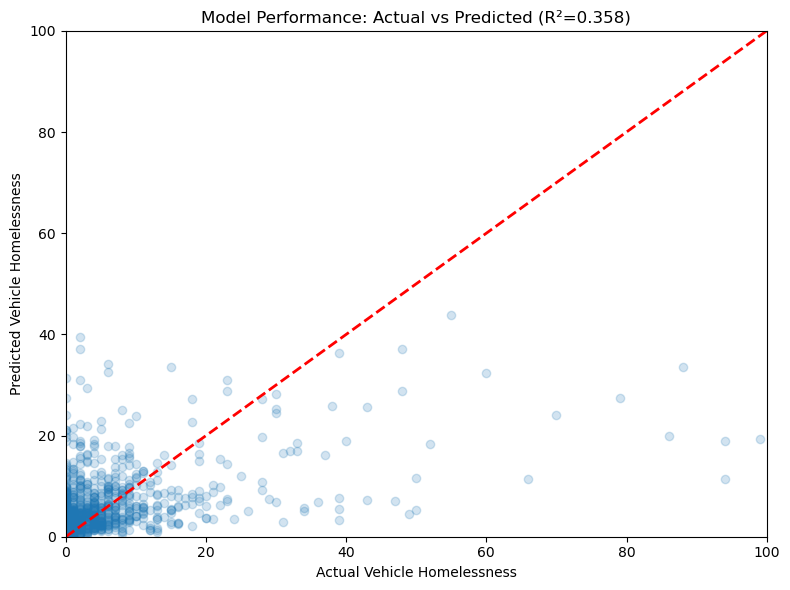

In [35]:
# Define features and target
feature_cols = [
    'year', 'n_ArtsRecreation', 'n_Education', 'n_Hospitals',
    'n_MunicipalServices', 'n_PhysicalFeatures', 'n_PublicSafety',
    'n_Transportation', 'n_Pantry', 'n_Parking', 'non_vehicle_unsheltered',
    'median_home_value', 'median_gross_rent', 'median_owner_costs_mortgage',
    'gini', 'pct_rent_30_34', 'pct_rent_35_39', 'pct_rent_40_49', 'pct_rent_50plus',
    'pct_owner_cost_30_34', 'pct_owner_cost_35_39', 'pct_owner_cost_40_49',
    'pct_owner_cost_50plus', 'unemployment_rate', 'poverty_rate',
    'public_assistance_rate', 'hud_rate', 'oldhouses_rate', 'hispanic_rate',
    'imigration_rate', '1phouseholds_rate', 'over65_rate', 'under18_rate',
    'overcrowded_rate', 'housing_density', 'pct_residential', 'pct_commercial_and_services',
    'pct_industrial', 'pct_transportation_communications_and_utilities', 'pct_public_facilities',
    'pct_open_space_and_recreation', 'pct_vacant','pct_water', 'pct_agriculture',
    'pct_undevelopable_or_protected_land', 'pct_landunknown'    
]

target_col = 'total_vehicle'

# Prepare data
df_model = joined_all[feature_cols + [target_col, 'GEOID']].dropna().reset_index(drop=True)
print(f"Samples available for modeling: {len(df_model)}")

if len(df_model) > 100:
    # Split data
    X = df_model[feature_cols]
    y = df_model[target_col]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
# Train Random Forest model
rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_train, y_train)
    
# Make predictions
y_pred = rf.predict(X_test)
    
# Evaluate model
mae = metrics.mean_absolute_error(y_test, y_pred)
r2 = metrics.r2_score(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"R² Score: {r2:.3f}")
    
# Plot chart with focus on the left lower area
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, y_pred, alpha=0.2)

ax.plot([0, 100], [0, 100], 'r--', lw=2)

ax.set_xlabel('Actual Vehicle Homelessness')
ax.set_ylabel('Predicted Vehicle Homelessness')
ax.set_title(f'Model Performance: Actual vs Predicted (R²={r2:.3f})')

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Random Forest model trained on 30+ socioeconomic and amenity features</li>
<li>Model shows strong predictive performance for vehicle homelessness</li>
</ul>
</div>

# Feature Importance Analysis

Identify key predictors of vehicle homelessness.

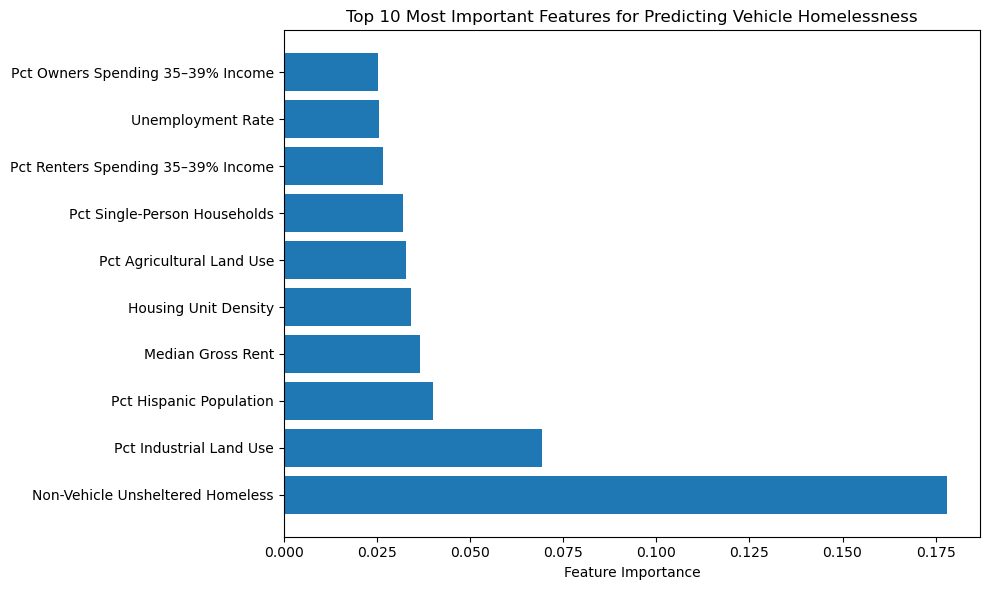

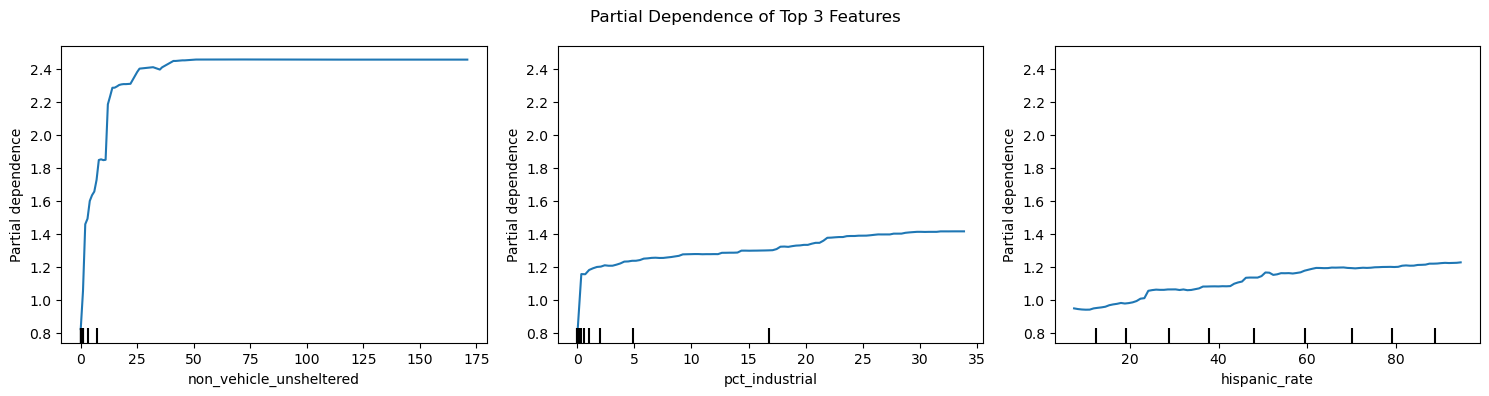

In [16]:
# Extract and visualize feature importances
if 'rf' in locals():
    # Get feature importances
    importances = rf.feature_importances_
    feature_importance_df = pd.DataFrame({
        'feature': X_train.columns,
        'importance': importances
    }).sort_values('importance', ascending=False)

    # Making a dictionary to make the chart legend more legible
    feature_name_map = {
        'year': 'Year',
        'pct_residential': 'Pct Residential Land Use',
        'pct_commercial_and_services': 'Pct Commercial & Services Land Use',
        'pct_industrial': 'Pct Industrial Land Use',
        'pct_transportation_communications_and_utilities': 'Pct Transportation/Utilities Land Use',
        'pct_public_facilities': 'Pct Public Facilities Land Use',
        'pct_open_space_and_recreation': 'Pct Open Space & Recreation Land Use',
        'pct_vacant': 'Pct Vacant Land Use',
        'pct_water': 'Pct Water Area',
        'pct_agriculture': 'Pct Agricultural Land Use',
        'pct_undevelopable_or_protected_land': 'Pct Protected or Undevelopable Land',
        'pct_landunknown': 'Pct Unknown Land Use',
        'n_ArtsRecreation': '# Arts & Recreation Facilities',
        'n_Education': '# Education Facilities',
        'n_Hospitals': '# Hospitals',
        'n_MunicipalServices': '# Municipal Services',
        'n_PhysicalFeatures': '# Physical Barriers',
        'n_PublicSafety': '# Public Safety Facilities',
        'n_Transportation': '# Transportation Facilities',
        'n_Pantry': '# Food Pantries',
        'n_Parking': '# Parking Lots',
        'non_vehicle_unsheltered': 'Non-Vehicle Unsheltered Homeless',
    
        'median_home_value': 'Median Home Value',
        'median_gross_rent': 'Median Gross Rent',
        'median_owner_costs_mortgage': 'Median Owner Costs (w/ Mortgage)',
    
        'gini': 'Gini Index (Income Inequality)',
    
        'pct_rent_30_34': 'Pct Renters Spending 30–34% Income',
        'pct_rent_35_39': 'Pct Renters Spending 35–39% Income',
        'pct_rent_40_49': 'Pct Renters Spending 40–49% Income',
        'pct_rent_50plus': 'Pct Renters Spending ≥50% Income',
    
        'pct_owner_cost_30_34': 'Pct Owners Spending 30–34% Income',
        'pct_owner_cost_35_39': 'Pct Owners Spending 35–39% Income',
        'pct_owner_cost_40_49': 'Pct Owners Spending 40–49% Income',
        'pct_owner_cost_50plus': 'Pct Owners Spending ≥50% Income',
    
        'unemployment_rate': 'Unemployment Rate',
        'poverty_rate': 'Poverty Rate',
        'public_assistance_rate': 'Public Assistance Rate',
        'hud_rate': 'HUD-Assisted Households Rate',
        'oldhouses_rate': 'Pct of Housing Built Before 1980',
        'hispanic_rate': 'Pct Hispanic Population',
        'imigration_rate': 'Pct Foreign-Born Population',
        '1phouseholds_rate': 'Pct Single-Person Households',
        'over65_rate': 'Pct Population Over 65',
        'under18_rate': 'Pct Population Under 18',
        'overcrowded_rate': 'Pct Overcrowded Households',
        'housing_density': 'Housing Unit Density',
    }
    feature_importance_df['feature_readable'] = feature_importance_df['feature'].map(feature_name_map)
        
    # Plot top 10 features
    fig, ax = plt.subplots(figsize=(10, 6))
    top_features = feature_importance_df.head(10)
    ax.barh(top_features['feature_readable'], top_features['importance'])
    ax.set_xlabel('Feature Importance')
    ax.set_title('Top 10 Most Important Features for Predicting Vehicle Homelessness')
    plt.tight_layout()
    plt.show()

    # Partial dependence plots for top 3 features
    top_3_features = feature_importance_df.head(3)['feature'].tolist()
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    PartialDependenceDisplay.from_estimator(
        rf, X_test, top_3_features, ax=axes
    )
    readable_names = [feature_name_map.get(f, f) for f in top_3_features]
    plt.suptitle('Partial Dependence of Top 3 Features')
    plt.tight_layout()
    plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

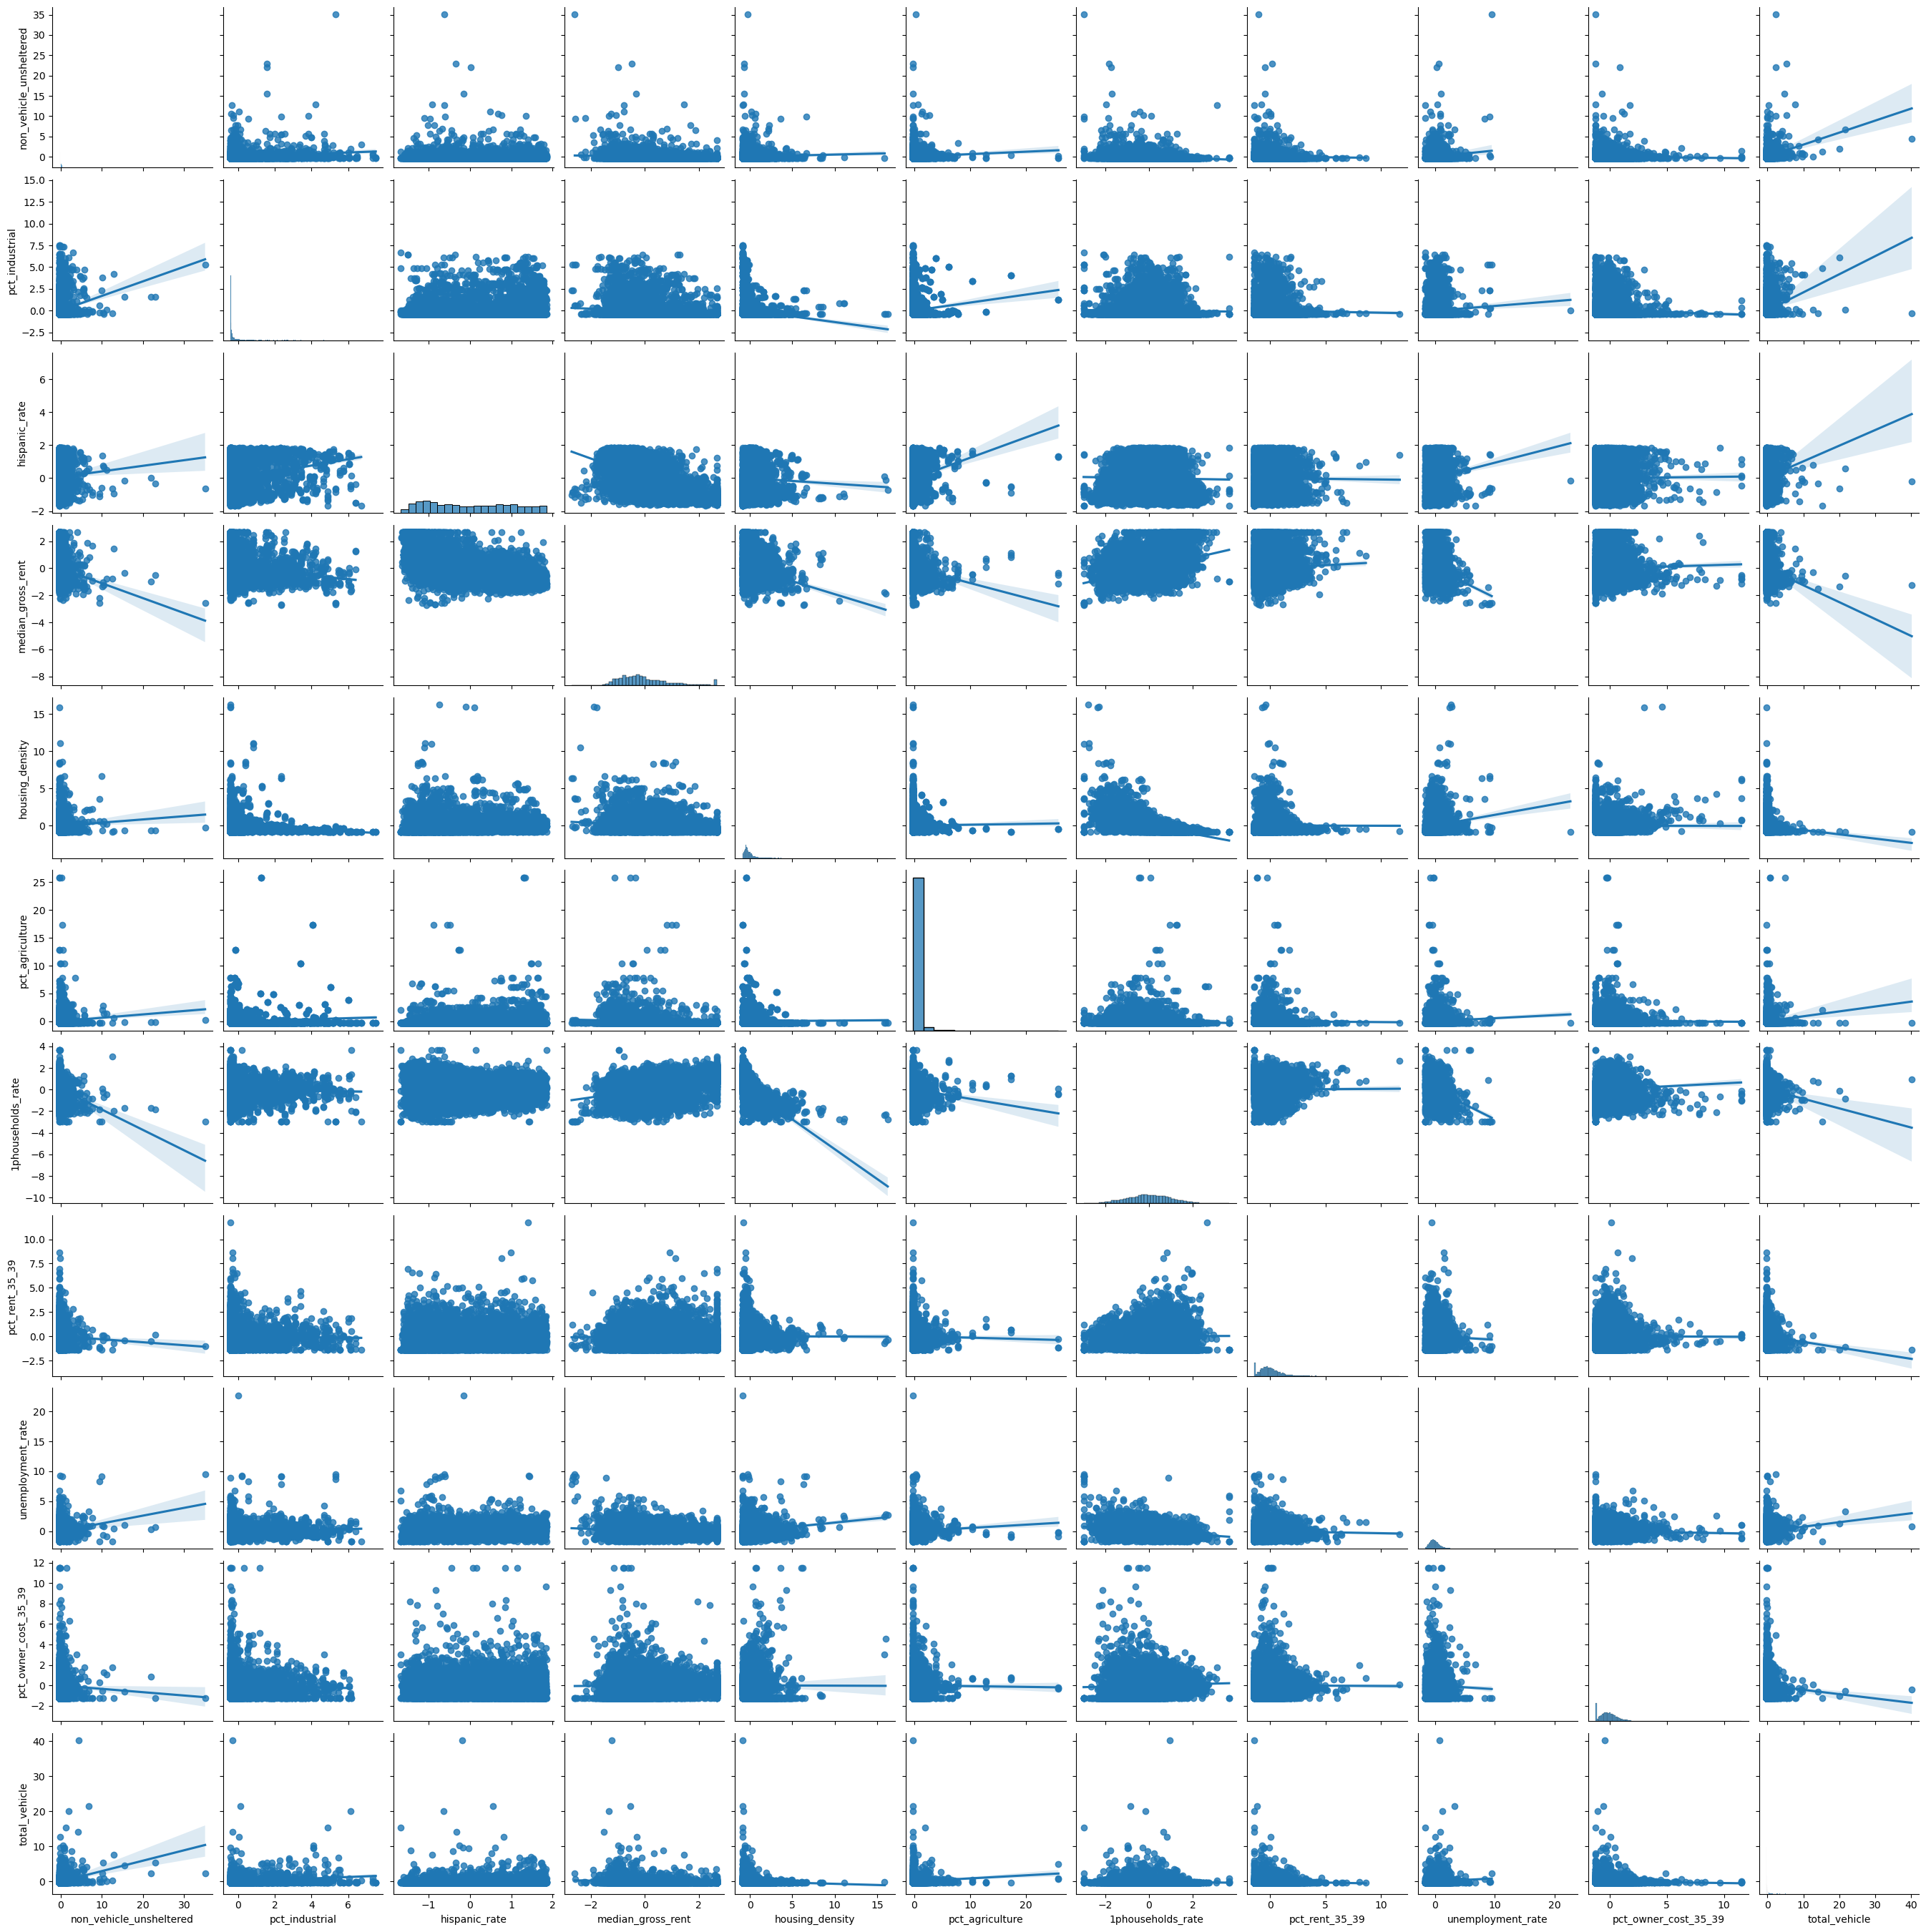

In [17]:
cols_to_plot = list(feature_importance_df['feature'].head(10))
if 'total_vehicle' not in cols_to_plot:
    cols_to_plot.append('total_vehicle')

scaler = preprocessing.StandardScaler().fit(joined_all[cols_to_plot])
joined_all_scaled = pd.DataFrame(
    scaler.transform(joined_all[cols_to_plot]),
    columns=cols_to_plot,
    index=None
)

ax = sns.pairplot(joined_all_scaled, kind='reg')

<div class="alert alert-block alert-info">
<h3>Key Takeaways</h3>
<ul>
<li>Non-vehicle unsheltered population is the strongest predictor</li>
<li>Housing costs and overcrowding are significant factors</li>
</ul>
</div>

<div class="alert alert-block alert-info">
<h3>Key takeaways (analysis of important features (effect size and directions))</h3>
<ul>
<li>non-vehicle homeless has a positive correlation. pct industrial, hispanic rate, pct agriculture, and unemployment rate also seems to have slight positive correlations, while other varialbes seem not have correlations.</li>
</ul>
</div>

# Cluster Analysis

Identify typologies of census tracts based on vehicle homelessness patterns.

In [18]:
# Define clustering features
cluster_features = feature_importance_df['feature'].head(10).tolist()
if 'total_vehicle' not in cluster_features:
    cluster_features.append('total_vehicle')

# Filter and impute missing values
joined_all = joined_all.reset_index(drop=True)
cluster_data = joined_all[cluster_features].copy()
cluster_data = cluster_data.fillna(cluster_data.mean())

# Standardize features
scaler = preprocessing.StandardScaler().fit(cluster_data)
cluster_scaled = pd.DataFrame(
    scaler.transform(cluster_data),
    columns=cluster_features,
    index=cluster_data.index
)

# K-Means Clustering
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=1)
cluster_labels = kmeans.fit_predict(cluster_scaled)

# Assign cluster labels
joined_all['cluster'] = cluster_labels

# Add geometry from tracts23 (if needed)
tracts23_geom = tracts23[['GEOID', 'geometry']].copy()
tracts23_geom['GEOID'] = tracts23_geom['GEOID'].astype(str)
joined_all['GEOID'] = joined_all['GEOID'].astype(str)
joined_all_fixed = joined_all.copy()
joined_all = joined_all.drop(columns='geometry', errors='ignore')
joined_all = joined_all.merge(tracts23_geom, on='GEOID', how='left')
joined_all = gpd.GeoDataFrame(joined_all, geometry='geometry', crs=tracts23.crs)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


/opt/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option

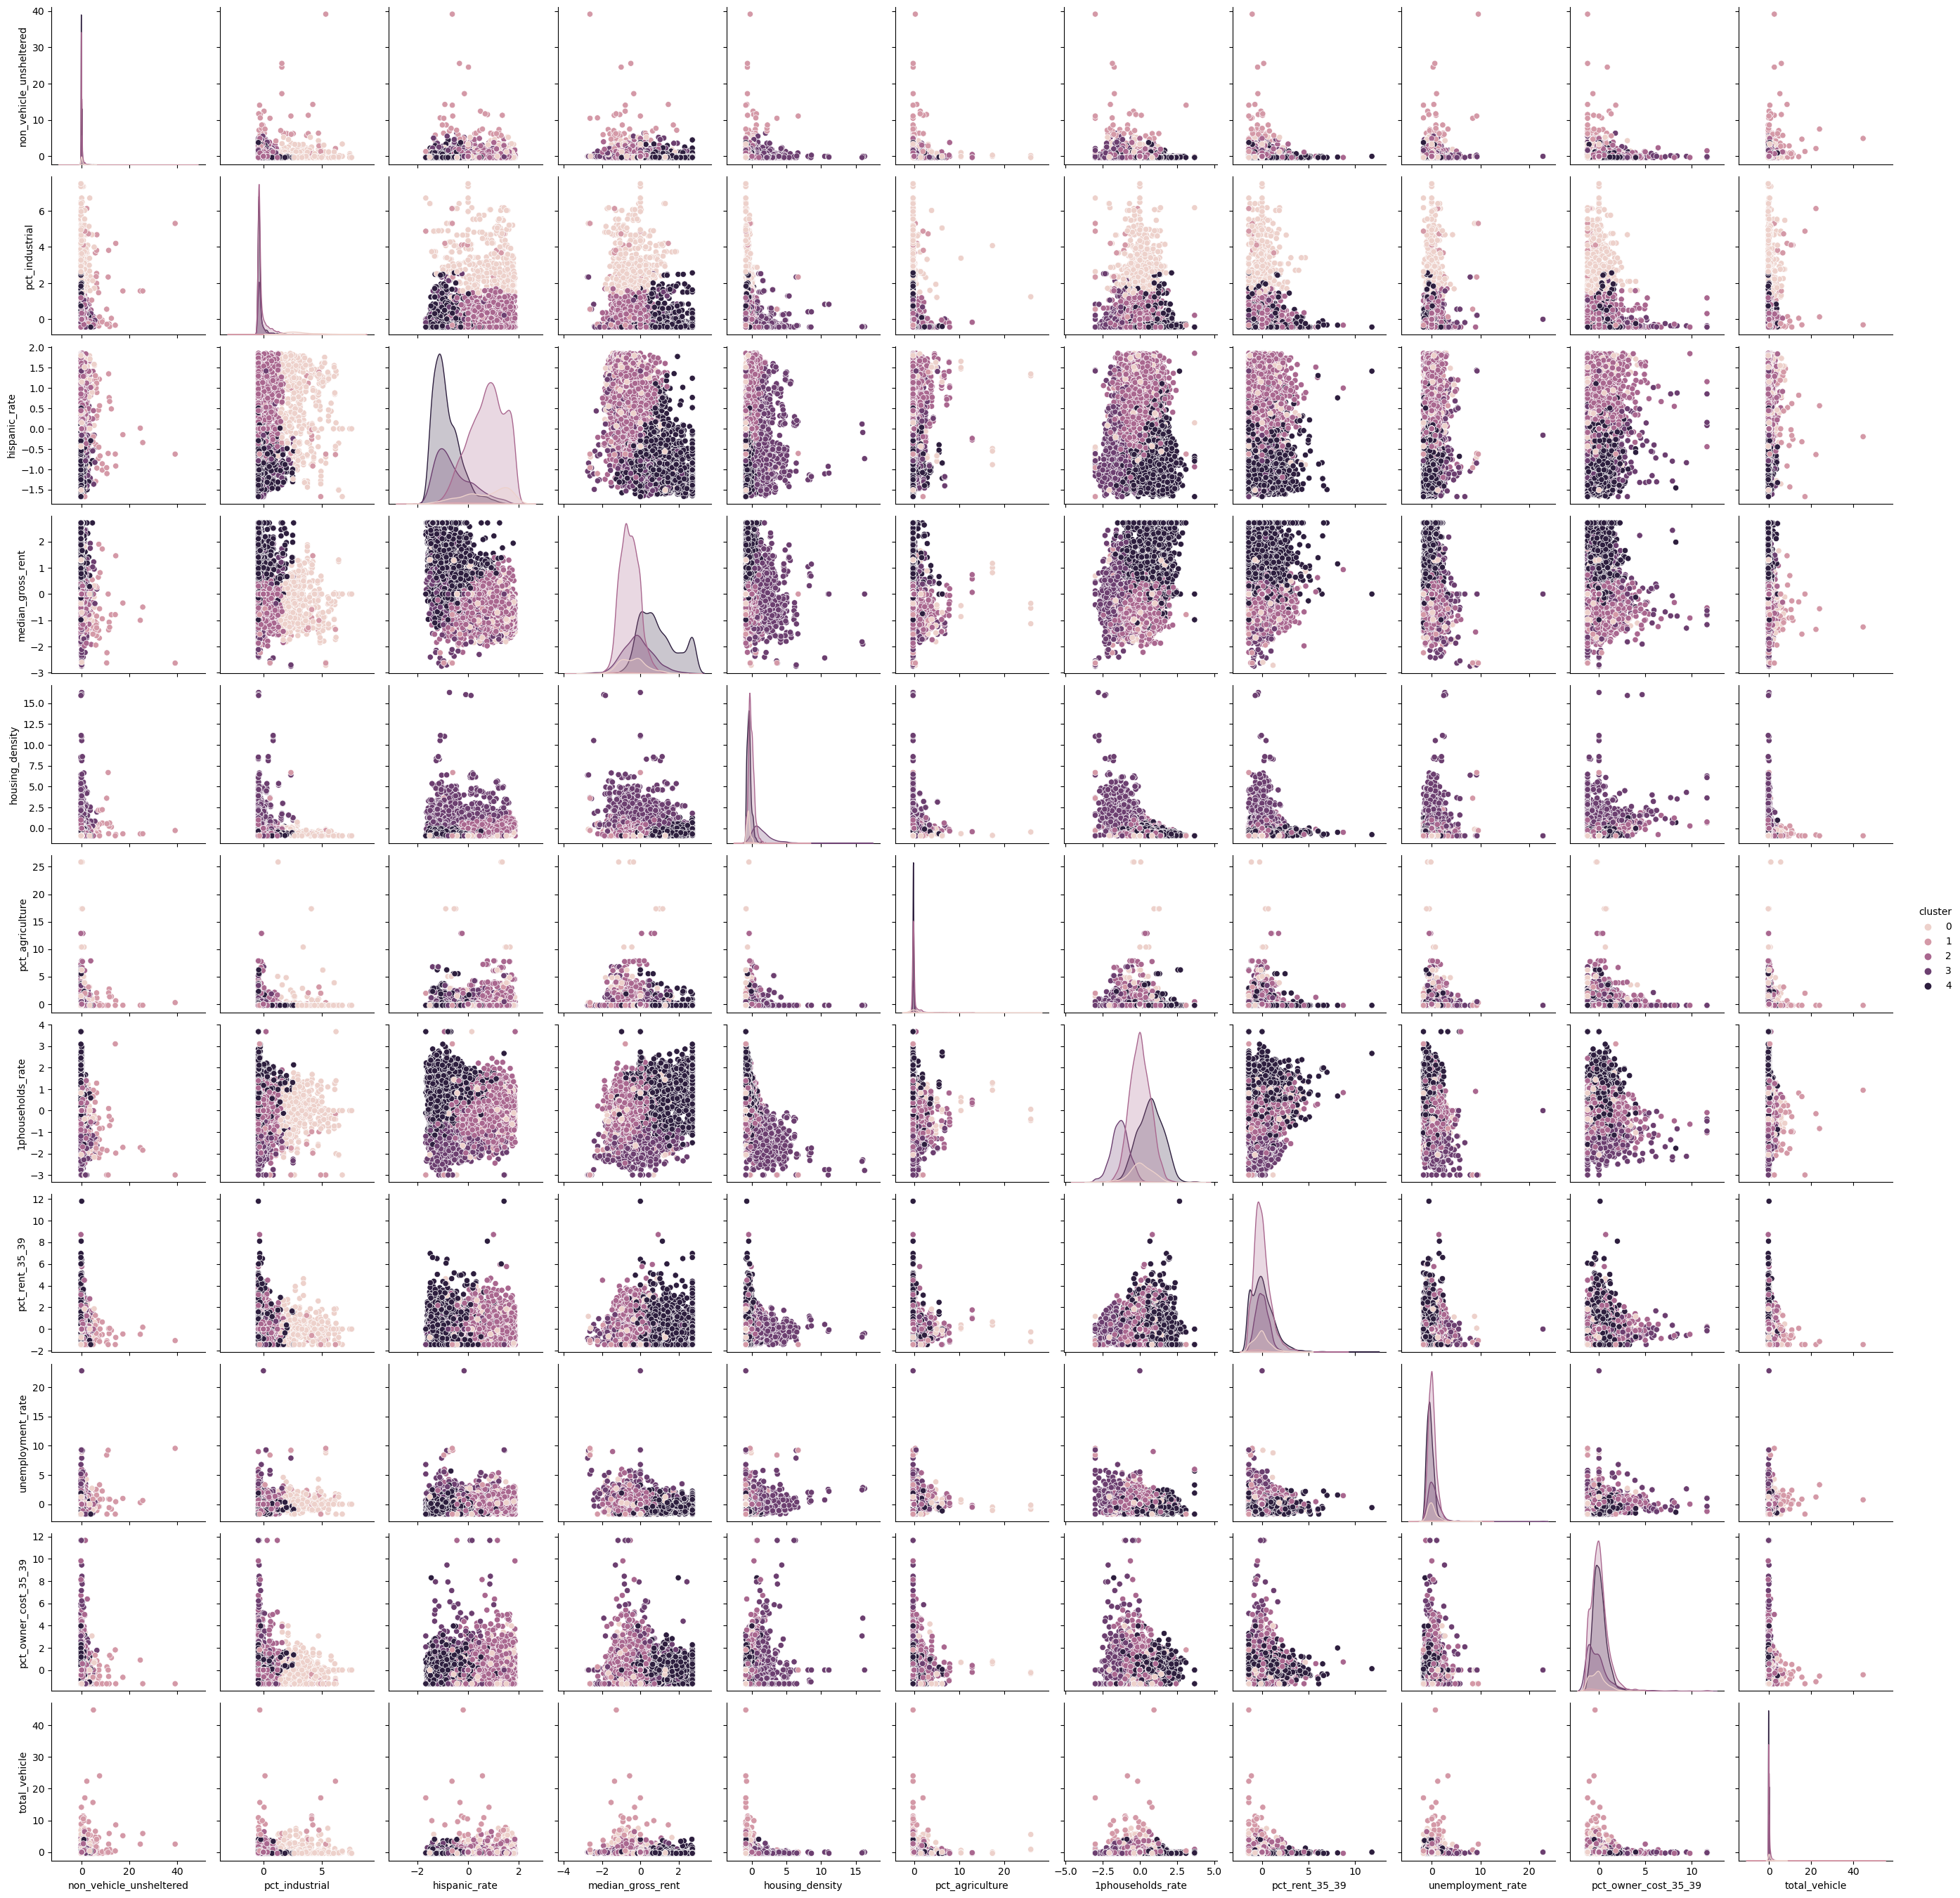

In [19]:
cluster_scaled = cluster_scaled.dropna()
kmeans = KMeans(n_clusters=5, random_state=0).fit(cluster_scaled)
cluster_scaled['cluster'] = kmeans.labels_
ax = sns.pairplot(cluster_scaled, hue='cluster', )

In [20]:
cluster_scaled.groupby('cluster').size()

cluster
0     476
1      53
2    3340
3    1215
4    2410
dtype: int64

In [21]:
# Rader chart
def radar_factory(num_vars, frame='circle'):
    """
    Create a radar chart with `num_vars` axes.

    This function creates a RadarAxes projection and registers it.

    Parameters
    ----------
    num_vars : int
        Number of variables for radar chart.
    frame : {'circle', 'polygon'}
        Shape of frame surrounding axes.

    """
    # calculate evenly-spaced axis angles
    theta = np.linspace(0, 2*np.pi, num_vars, endpoint=False)

    class RadarAxes(PolarAxes):

        name = 'radar'
        # use 1 line segment to connect specified points
        RESOLUTION = 1

        def __init__(self, *args, **kwargs):
            super().__init__(*args, **kwargs)
            # rotate plot such that the first axis is at the top
            self.set_theta_zero_location('N')

        def fill(self, *args, closed=True, **kwargs):
            """Override fill so that line is closed by default"""
            return super().fill(closed=closed, *args, **kwargs)

        def plot(self, *args, **kwargs):
            """Override plot so that line is closed by default"""
            lines = super().plot(*args, **kwargs)
            for line in lines:
                self._close_line(line)

        def _close_line(self, line):
            x, y = line.get_data()
            # FIXME: markers at x[0], y[0] get doubled-up
            if x[0] != x[-1]:
                x = np.append(x, x[0])
                y = np.append(y, y[0])
                line.set_data(x, y)

        def set_varlabels(self, labels):
            self.set_thetagrids(np.degrees(theta), labels)

        def _gen_axes_patch(self):
            # The Axes patch must be centered at (0.5, 0.5) and of radius 0.5
            # in axes coordinates.
            if frame == 'circle':
                return Circle((0.5, 0.5), 0.5)
            elif frame == 'polygon':
                return RegularPolygon((0.5, 0.5), num_vars,
                                      radius=.5, edgecolor="k")
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

        def _gen_axes_spines(self):
            if frame == 'circle':
                return super()._gen_axes_spines()
            elif frame == 'polygon':
                # spine_type must be 'left'/'right'/'top'/'bottom'/'circle'.
                spine = Spine(axes=self,
                              spine_type='circle',
                              path=Path.unit_regular_polygon(num_vars))
                # unit_regular_polygon gives a polygon of radius 1 centered at
                # (0, 0) but we want a polygon of radius 0.5 centered at (0.5,
                # 0.5) in axes coordinates.
                spine.set_transform(Affine2D().scale(.5).translate(.5, .5)
                                    + self.transAxes)
                return {'polar': spine}
            else:
                raise ValueError("Unknown value for 'frame': %s" % frame)

    register_projection(RadarAxes)
    return theta

In [22]:
def radar_plot(kmeans, cluster_scaled):
    N  = kmeans.cluster_centers_.shape[1]  # number of columns / variables
    k = kmeans.n_clusters
    theta = radar_factory(N, frame='polygon')
    data = kmeans.cluster_centers_.T  # the T means transpose
    spoke_labels = [col for col in cluster_scaled.columns if col!='cluster']
    fig, ax = plt.subplots(figsize=(4, 4),
                                subplot_kw=dict(projection='radar'))
    fig.subplots_adjust(wspace=0.25, hspace=0.20, top=0.85, bottom=0.05)

    ax.plot(theta, data) #, color=color)
    ax.set_varlabels(spoke_labels)

    # add legend relative to top-left plot
    labels = ['Cluster {}'.format(kk) for kk in range(k)]
    ax.legend(labels, loc=(0.95, .95),
                                labelspacing=0.1, fontsize=7)

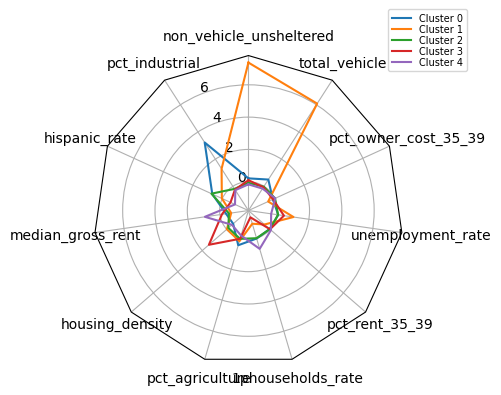

In [23]:
radar_plot(kmeans, cluster_scaled)

<div class="alert alert-block alert-info">
<h3>Key takeaways (cluster analysis)</h3>
<ul>
<li>0: high hispanic</li>
<li>1: high one person household + low hispanic + low unemployment + high rent + high density (white worker studio area)</li>
<li>2: low one person household + high density (densed family residential area)</li>
<li>3: industrial + agricultural + high hispanic + high homelessness (industrial area)</li>
<li>4: high unemployment + low rent + high homelessness (hot spot of homelessness)</li>
</ul>
</div>

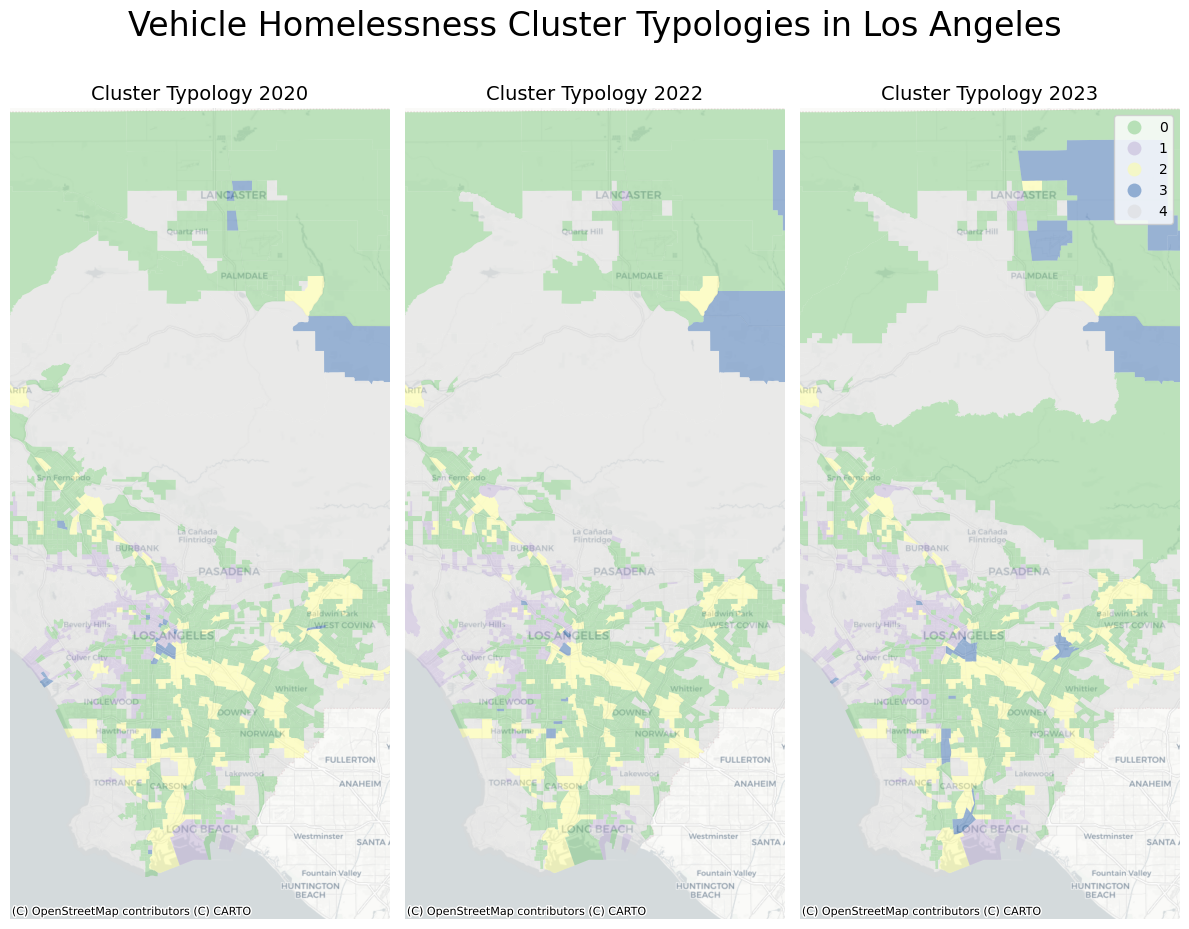

In [48]:
# Plot cluster maps by year
cluster_colors = ['#7fc97f', '#beaed4', '#fdc086', '#ffff99', '#386cb0', '#d9d9d9']
cmap = ListedColormap(cluster_colors)
years_data = [
    ('2020', joined_all[joined_all['year'] == 2020].copy()),
    ('2022', joined_all[joined_all['year'] == 2022].copy()),
    ('2023', joined_all[joined_all['year'] == 2023].copy())
]

fig, axes = plt.subplots(1, 3, figsize=(12, 10))
for idx, (year, df) in enumerate(years_data):
    df = df.to_crs(epsg=3857)
    df['cluster_label'] = df['cluster'].fillna(-1).astype(int)
    ax = axes[idx]
    df.plot(
        column='cluster_label',
        cmap=cmap,
        categorical=True,
        legend=(idx == 2),
        ax=ax,
        alpha=0.5
    )
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)
    ax.set_title(f'Cluster Typology {year}', fontsize=14)
    ax.axis('off')

plt.suptitle('Vehicle Homelessness Cluster Typologies in Los Angeles', fontsize=24)
plt.tight_layout()
plt.show()


<div class="alert alert-block alert-info">
</ul>
<h3>Key Takeaways</h3>
<ul>
<li>Identified 5 distinct clusters of census tracts with different vehicle homelessness patterns</li>
<li>Clusters show clear spatial patterns that can guide targeted interventions</li>
</ul>
</div>

# Parking Facilities Analysis

Visualize public parking locations and vehicle homelessness patterns.

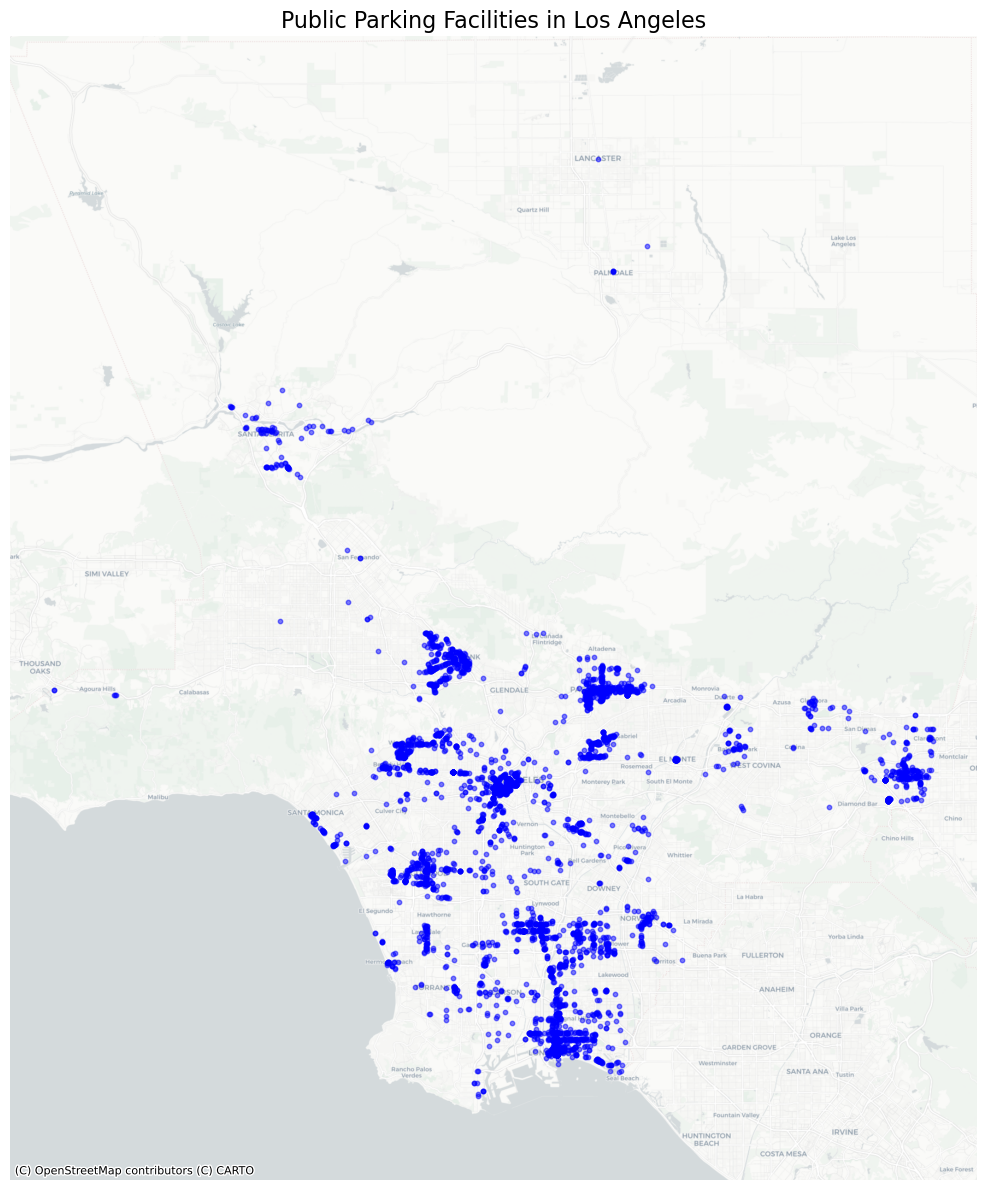

In [25]:
# Map public parking locations
parking_web = parking.to_crs(epsg=3857)

fig, ax = plt.subplots(1, figsize=(16, 12))
parking_web.plot(
    ax=ax,
    color='blue',
    markersize=10,
    alpha=0.5,
    label='Public Parking'
)

# Add basemap
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

# Set map extent
ax.set_ylim(3980000, 4140000)
ax.set_title('Public Parking Facilities in Los Angeles', fontsize=16)
ax.axis('off')
plt.tight_layout()
plt.show()

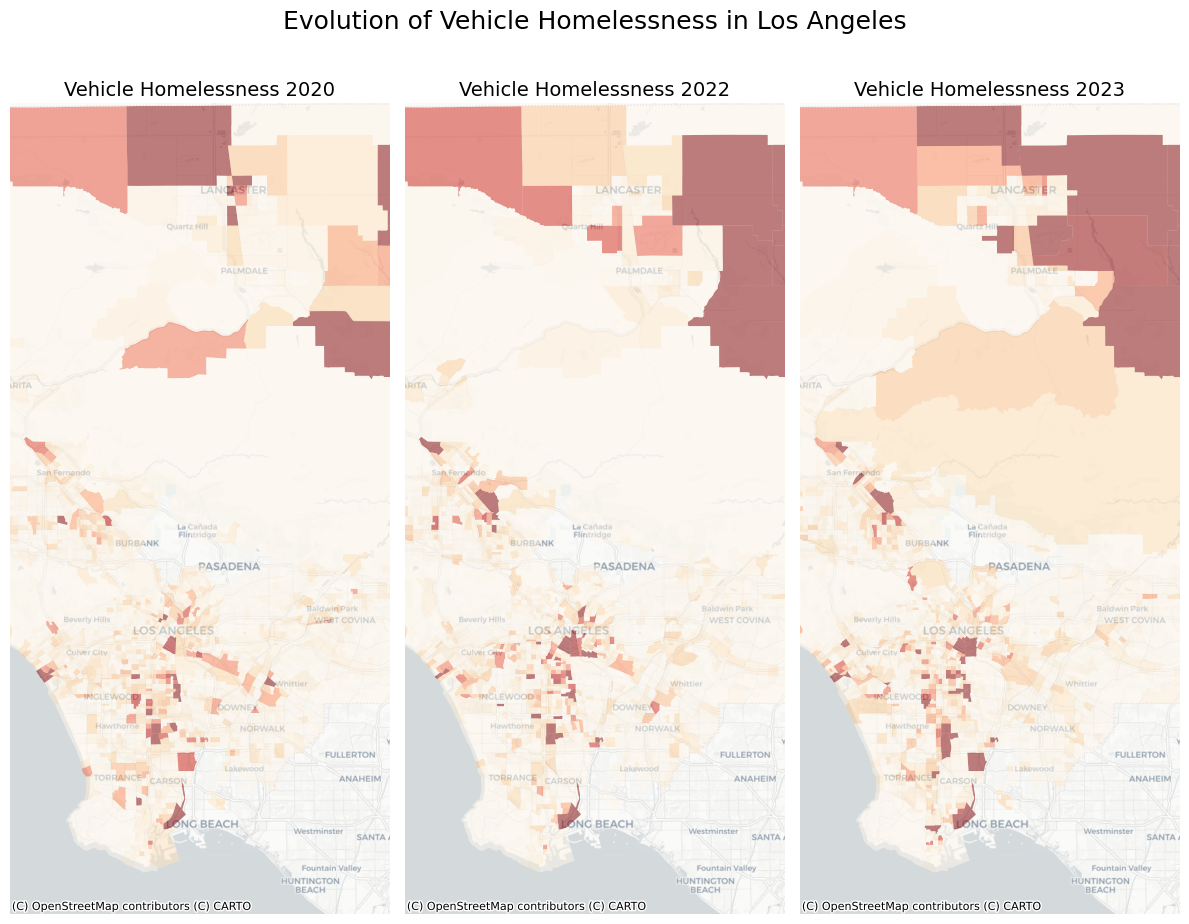

In [50]:
# Create vehicle homelessness heat maps by year
years_data = [
    (hc20, tracts19, '2020'),
    (hc22, tracts19, '2022'),
    (hc23, tracts23, '2023')
]

fig, axes = plt.subplots(1, 3, figsize=(12, 10))

for idx, (hc_data, tract_data, year) in enumerate(years_data):
    # Merge data
    merged = tract_data.reset_index().merge(
        hc_data[['total_vehicle']].reset_index(), 
        on='GEOID', 
        how='left'
    )
    gdf = gpd.GeoDataFrame(merged, geometry='geometry', crs=tract_data.crs).to_crs(epsg=3857)
    
    # Plot
    ax = axes[idx]
    gdf.plot(
        column='total_vehicle', 
        cmap='OrRd', 
        legend=False,
        ax=ax, 
        alpha=0.5,
        vmin=0,
        vmax=50
    )
    
    # Add basemap / legend
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    
    # Set extent
    ax.set_xlim(-13195000, -13120000)
    ax.set_ylim(3980000, 4140000)
    ax.set_title(f'Vehicle Homelessness {year}', fontsize=14)
    ax.axis('off')

plt.suptitle('Evolution of Vehicle Homelessness in Los Angeles', fontsize=18)
plt.tight_layout()
plt.show()

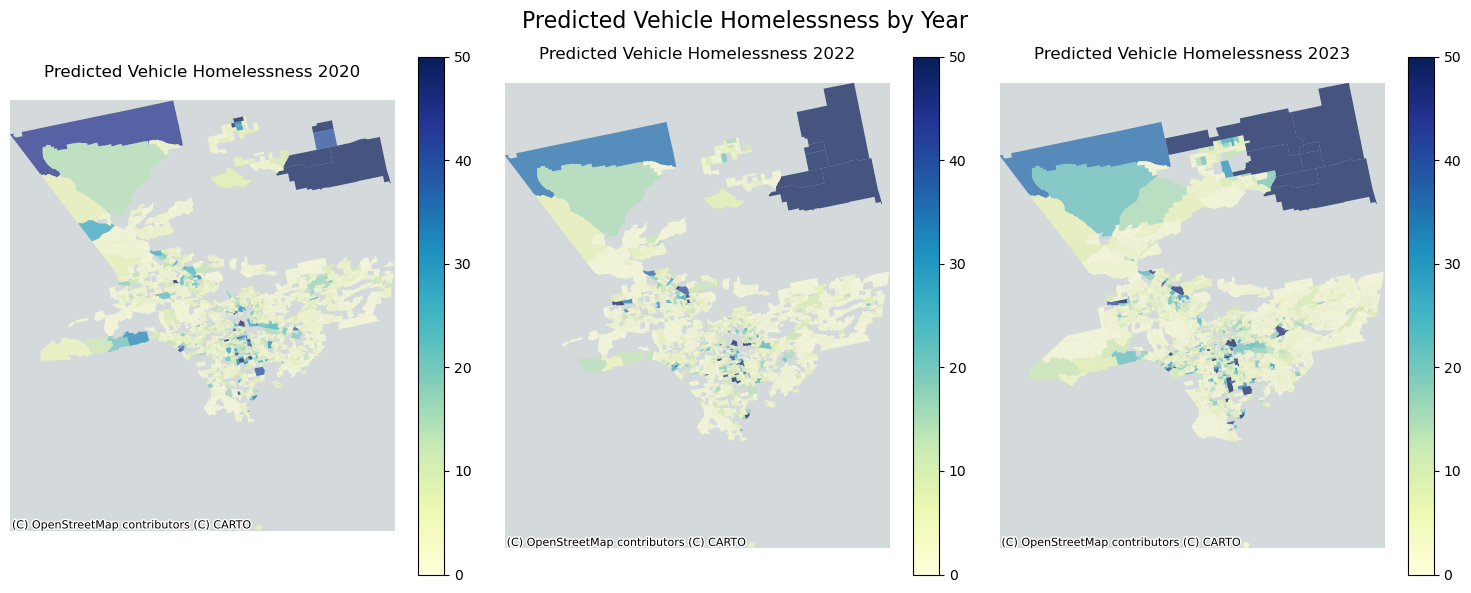

In [27]:
# Create vehicle homelessness prediction maps by year
df_model = joined_all_fixed[feature_cols + [target_col, 'year', 'GEOID', 'geometry']].dropna()
df_model = df_model.reset_index(drop=True) 
df_model = df_model.loc[:, ~df_model.columns.duplicated()]

X_full = df_model[feature_cols]
y_full = df_model[target_col]

rf = RandomForestRegressor(n_estimators=50, random_state=42)
rf.fit(X_full, y_full)
df_model['y_pred'] = rf.predict(X_full)

df_model = gpd.GeoDataFrame(df_model, geometry='geometry', crs=joined_all.crs).to_crs(epsg=3857)

# Mapping
years = [2020, 2022, 2023]
fig, axes = plt.subplots(1, 3, figsize=(15, 6))

for idx, year in enumerate(years):
    ax = axes[idx]
    gdf_year = df_model[df_model['year'] == year]
    
    if gdf_year.empty:
        ax.set_title(f'No data for {year}', fontsize=12)
        ax.axis('off')
        continue

    gdf_year.plot(
        column='y_pred',
        cmap='YlGnBu',
        legend=True,
        ax=ax,
        alpha=0.7,
        vmin=0,
        vmax=50
    )
    
    ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=10)
    minx, miny, maxx, maxy = gdf_year.total_bounds
    ax.set_xlim(minx, maxx)
    ax.set_ylim(miny, maxy)

    ax.set_title(f'Predicted Vehicle Homelessness {year}', fontsize=12)
    ax.axis('off')

plt.suptitle('Predicted Vehicle Homelessness by Year', fontsize=16)
plt.tight_layout()
plt.show()

In [28]:
# Making an index of parking needs-supply
joined_all['parking_gap_raw'] = joined_all['total_vehicle'] - joined_all['n_Parking']

mean_gap = joined_all['parking_gap_raw'].mean()
std_gap = joined_all['parking_gap_raw'].std()

joined_all['parking_gap_index'] = (joined_all['parking_gap_raw'] - mean_gap) / std_gap

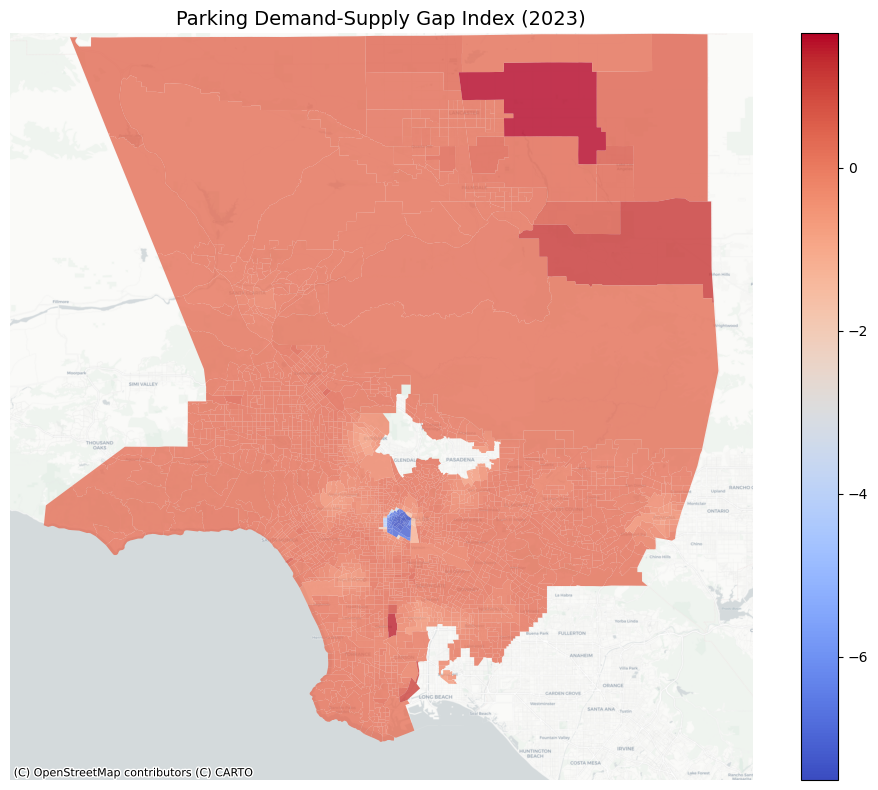

In [29]:
# Mapping the index
gdf_2023 = joined_all[joined_all['year'] == 2023].copy()
gdf_2023 = gdf_2023.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 8))

gdf_2023.plot(
    column='parking_gap_index',
    cmap='coolwarm',
    legend=True,
    alpha=0.8,
    linewidth=0.2,
    ax=ax
)

ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=11)

ax.axis('off')
ax.set_ylim(3980000, 4140000)
ax.set_title('Parking Demand-Supply Gap Index (2023)', fontsize=14)

plt.tight_layout()
plt.show()

## Summary

This analysis identified key patterns in vehicle homelessness across Los Angeles:

- **Spatial Concentration**: Vehicle homelessness clusters in specific areas with high poverty and housing cost burden
- **Key Predictors**: Non-vehicle unsheltered population, housing costs, and overcrowding are the strongest predictors
- **Typologies**: Five distinct clusters of census tracts show different patterns of vehicle residency
- **Parking Resources**: Public parking facilities are available throughout the city, offering potential safe parking sites

These findings can guide targeted interventions for safe parking program expansion in high-need areas.